# OSQ Sleep Questionnaire Analysis

This notebook analyzes the Oviedo Sleep Questionnaire (OSQ) scores 
across intervention visits for the AI4Food crossover study.

**Study Design:**
- Group 1: Traditional phase V1 → V2
- Group 2: Traditional phase V2 → V3

**Statistical test:** Wilcoxon signed-rank test (non-parametric, paired)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv('data/cos__2_.tsv', sep='\t')
df['puntuacion_total'] = pd.to_numeric(df['puntuacion_total'], errors='coerce')
df = df.dropna(subset=['puntuacion_total', 'visita', 'id_voluntario'])
df.head()

,id_voluntario,id_cuestionario,fecha_cuestionario,visita,1_satisfaccion_sueno,2_1_conciliar_sueno,2_2_permanecer_dormido,2_3_sueno_reparador,2_4_despertar_habitual,2_5_excesiva_somnolencia,...,10d_dias_pesadillas,10e_dias_otros,10e_otros_especificar,11_dias_ayudas_sueno,11b_tipo_ayudas_sueno,puntuacion_satisfaccion_sueno,puntuacion_insomnio,puntuacion_hipersomnia,puntuacion_total,observaciones
0,1045,cos_v1_1045,2022-05-19,1,6,1,1,2,2,1,...,1,1,\N,1,\N,6,12,3,21,\N
1,1077,cos_v1_1077,2022-05-23,1,5,1,1,2,4,3,...,1,1,\N,1,\N,5,16,8,29,\N
2,1100,cos_v1_1100,2022-05-18,1,5,2,5,4,5,1,...,1,1,\N,1,\N,5,23,3,31,\N
3,1220,cos_v1_1220,2022-05-23,1,5,2,2,2,1,1,...,1,1,\N,5,"Lormetazepam, Trazodona",5,21,6,32,\N
4,1251,cos_v1_1251,2022-05-19,1,2,1,1,1,1,2,...,1,1,\N,1,\N,2,10,4,16,\N


Group 1 | n=49 | Before=26.0 | After=25.0 | p=0.4474
Group 2 | n=47 | Before=27.0 | After=25.0 | p=0.0255


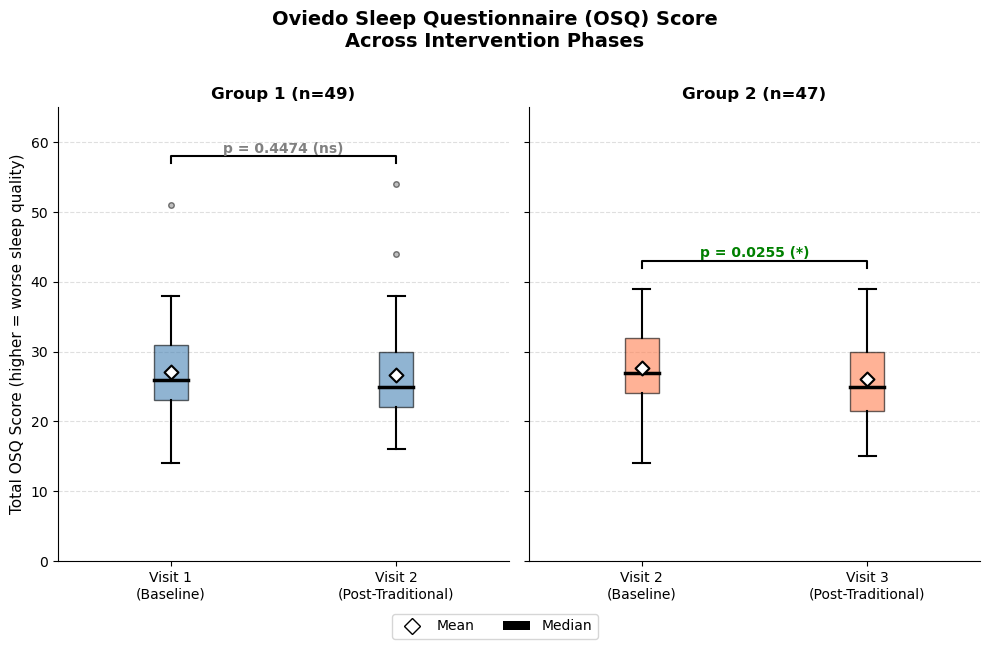

In [8]:
os.makedirs('figures', exist_ok=True)

v1_ids = set(df[df['visita']==1]['id_voluntario'])
v2_ids = set(df[df['visita']==2]['id_voluntario'])
v3_ids = set(df[df['visita']==3]['id_voluntario'])

group1_ids = v1_ids & v2_ids
group2_ids = v2_ids & v3_ids

g1_v1 = df[(df['visita']==1) & (df['id_voluntario'].isin(group1_ids))]['puntuacion_total'].values
g1_v2 = df[(df['visita']==2) & (df['id_voluntario'].isin(group1_ids))]['puntuacion_total'].values
g2_v2 = df[(df['visita']==2) & (df['id_voluntario'].isin(group2_ids))]['puntuacion_total'].values
g2_v3 = df[(df['visita']==3) & (df['id_voluntario'].isin(group2_ids))]['puntuacion_total'].values


# Statistical tests (Wilcoxon)

_, p_g1 = stats.wilcoxon(g1_v1, g1_v2)
_, p_g2 = stats.wilcoxon(g2_v2, g2_v3)

print(f'Group 1 | n={len(g1_v1)} | Before={np.median(g1_v1):.1f} | After={np.median(g1_v2):.1f} | p={p_g1:.4f}')
print(f'Group 2 | n={len(g2_v2)} | Before={np.median(g2_v2):.1f} | After={np.median(g2_v3):.1f} | p={p_g2:.4f}')

# Figure

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
fig.suptitle('Oviedo Sleep Questionnaire (OSQ) Score\nAcross Intervention Phases',
             fontsize=14, fontweight='bold', y=1.01)

groups_data = [
    {'ax': axes[0], 'data': [g1_v1, g1_v2],
     'labels': ['Visit 1\n(Baseline)', 'Visit 2\n(Post-Traditional)'],
     'title': f'Group 1 (n={len(g1_v1)})', 'color': 'steelblue', 'pval': p_g1},
    {'ax': axes[1], 'data': [g2_v2, g2_v3],
     'labels': ['Visit 2\n(Baseline)', 'Visit 3\n(Post-Traditional)'],
     'title': f'Group 2 (n={len(g2_v2)})', 'color': 'coral', 'pval': p_g2}
]

for g in groups_data:
    ax = g['ax']
    bp = ax.boxplot(g['data'], patch_artist=True, labels=g['labels'],
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='gray',
                                   markersize=4, alpha=0.5, linestyle='none'))

    for patch in bp['boxes']:
        patch.set_facecolor(g['color'])
        patch.set_alpha(0.6)

    for i, data in enumerate(g['data']):
        ax.scatter(i+1, np.mean(data), marker='D', color='white',
                  edgecolors='black', s=50, zorder=5, linewidth=1.5)

    y_max = max([max(d) for d in g['data']]) + 3
    ax.plot([1, 1, 2, 2], [y_max, y_max+1, y_max+1, y_max], lw=1.5, color='black')
    sig = '***' if g['pval'] < 0.001 else '**' if g['pval'] < 0.01 else '*' if g['pval'] < 0.05 else 'ns'
    ax.text(1.5, y_max+1.5, f'p = {g["pval"]:.4f} ({sig})',
            ha='center', fontsize=10, fontweight='bold',
            color='green' if g['pval'] < 0.05 else 'gray')

    ax.set_title(g['title'], fontsize=12, fontweight='bold')
    ax.set_ylim(0, 65)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Total OSQ Score (higher = worse sleep quality)', fontsize=11)

diamond = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
                     markeredgecolor='black', markersize=8, label='Mean')
median_line = mpatches.Patch(facecolor='black', label='Median')
fig.legend(handles=[diamond, median_line], loc='lower center',
          ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(r'figures/osq_comparison.png', dpi=300, bbox_inches='tight')
plt.show()